## SIS

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7, Tcmb0=0.0, Neff=3.04, m_nu=None, Ob0=0.0)

from ler.lens_galaxy_population import LensGalaxyParameterDistribution
from ler.utils import append_json, get_param_from_json

In [2]:
lens1 = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="sis_galaxy",
    lens_functions = dict(
            cross_section_based_sampler="rejection_sampler_partial",
            cross_section="cross_section_sis",
        ),
    directory="../interpolator_json",
    #create_new_interpolator=True,
)

lens2 = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="sis_galaxy",
    lens_functions = dict(
            cross_section_based_sampler="importance_sampler_partial",
            cross_section="cross_section_sis",
        ),
    directory="../interpolator_json",
    #create_new_interpolator=True,
)

lens3 = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="sis_galaxy",
    lens_functions = dict(
            cross_section_based_sampler="rejection_sampler_full",
            cross_section="cross_section_sis",
        ),
    directory="../interpolator_json",
    #create_new_interpolator=True,
)

lens4 = LensGalaxyParameterDistribution(
    npool=6,
    lens_type="sis_galaxy",
    lens_functions = dict(
            cross_section_based_sampler="importance_sampler_full",
            cross_section="cross_section_sis",
        ),
    directory="../interpolator_json",
    #create_new_interpolator=True,
)


Initializing LensGalaxyParameterDistribution class...


Initializing OpticalDepth class

comoving_distance interpolator will be loaded from ../interpolator_json/comoving_distance/comoving_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
angular_diameter_distance interpolator will be loaded from ../interpolator_json/angular_diameter_distance/angular_diameter_distance_0.json
differential_comoving_volume interpolator will be loaded from ../interpolator_json/differential_comoving_volume/differential_comoving_volume_0.json
using ler available velocity dispersion function : velocity_dispersion_ewoud
velocity_dispersion_ewoud interpolator will be loaded from ../interpolator_json/velocity_dispersion/velocity_dispersion_ewoud_0.json
using ler available axis_ratio function : constant_values_n_size
using ler available axis_rotation_angle function : constant_values_n_size
using ler available 

In [3]:
param1 = lens1.sample_lens_parameters(20000)
# time = 1m 58.4s

sampling lens parameters with epl_shear_sl_parameters_rvs...


In [ ]:
param2 = lens2.sample_lens_parameters(20000)
# time = 14.5s

sampling lens parameters with epl_shear_sl_parameters_rvs...


In [ ]:
param3 = lens3.sample_lens_parameters(20000)
# time = 21.2s

sampling lens parameters with epl_shear_sl_parameters_rvs...


In [ ]:
param4 = lens4.sample_lens_parameters(20000)
# time = 15.8s

sampling lens parameters with epl_shear_sl_parameters_rvs...


In [7]:
# keep only 'zs', 'zl', 'sigma'
param1 = {k: v for k, v in param1.items() if k in ['zs', 'zl', 'sigma']}
param2 = {k: v for k, v in param2.items() if k in ['zs', 'zl', 'sigma']}
param3 = {k: v for k, v in param3.items() if k in ['zs', 'zl', 'sigma']}
param4 = {k: v for k, v in param4.items() if k in ['zs', 'zl', 'sigma']}

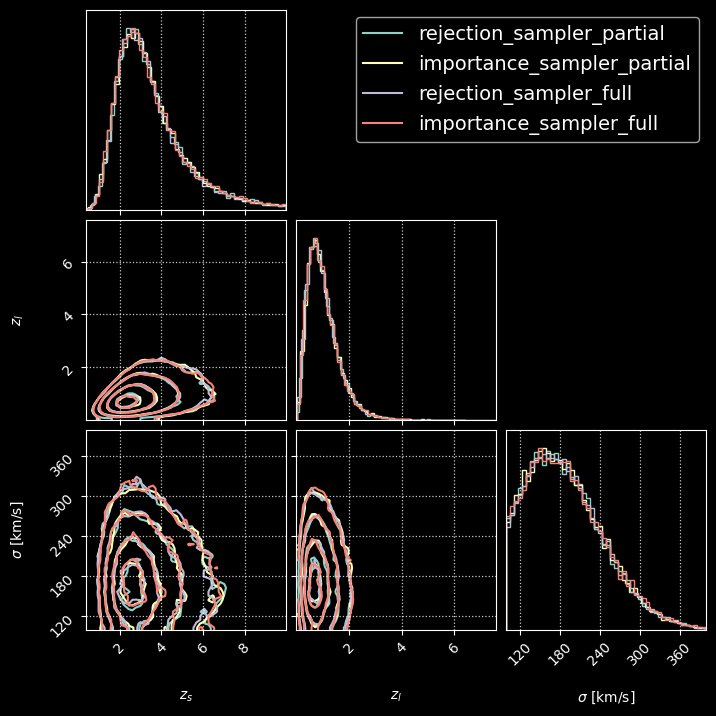

In [8]:
import corner
import matplotlib.lines as mlines

param_names = ['zs', 'zl', 'sigma']
labels = ['$z_s$', '$z_l$', r'$\sigma$ [km/s]']

samples1 = np.stack([param1[p] for p in param_names], axis=1)
samples2 = np.stack([param2[p] for p in param_names], axis=1)
samples3 = np.stack([param3[p] for p in param_names], axis=1)
samples4 = np.stack([param4[p] for p in param_names], axis=1)

fig = corner.corner(
    samples1, 
    labels=labels, 
    color='C0', 
    alpha=0.5,
    plot_density=False, 
    plot_datapoints=False, 
    bins=50,
    smooth=0.8,
    hist_kwargs={'density': True}
)

corner.corner(
    samples2, 
    labels=labels, 
    color='C1', 
    alpha=0.5,
    fig=fig,
    plot_density=False, 
    plot_datapoints=False, 
    bins=50,
    smooth=0.8,
    hist_kwargs={'density': True}
)

corner.corner(
    samples3, 
    labels=labels, 
    color='C2', 
    alpha=0.5,
    fig=fig,
    plot_density=False, 
    plot_datapoints=False, 
    bins=50,
    smooth=0.8,
    hist_kwargs={'density': True}
)

corner.corner(
    samples4, 
    labels=labels, 
    color='C3', 
    alpha=0.5,
    fig=fig,
    plot_density=False, 
    plot_datapoints=False, 
    bins=50,
    smooth=0.8,
    hist_kwargs={'density': True}
)

# Add grid lines
for ax in fig.axes:
    ax.set_axisbelow(False)

    ax.grid(
        True,
        which='major',
        linestyle=':',
        linewidth=0.9,
        alpha=0.8,
        zorder=10,
    )

# Add legend
green_line = mlines.Line2D([], [], color='C0', label='rejection_sampler_partial')
blue_line = mlines.Line2D([], [], color='C1', label='importance_sampler_partial')
red_line = mlines.Line2D([], [], color='C2', label='rejection_sampler_full')
orange_line = mlines.Line2D([], [], color='C3', label='importance_sampler_full')
fig.legend(handles=[green_line, blue_line, red_line, orange_line], loc='upper right', 
           bbox_to_anchor=(0.95, 0.95), fontsize=14)
plt.show()


## KS Score

In [17]:
from ler.utils import KStest

ks_score = KStest(param3, param4)
print('#--------------------------------#')
print('KS Score between rejection_sampler_full and importance_sampler_full')
print('#--------------------------------#')
for key, value in ks_score.items(): 
    print(f'{key}: {value}')

ks_score = KStest(param3, param2)
print('#--------------------------------#')
print('KS Score between rejection_sampler_full and importance_sampler_partial')
print('#--------------------------------#') 
for key, value in ks_score.items():
    print(f'{key}: {value}')

ks_score = KStest(param3, param1)
print('#--------------------------------#')
print('KS Score between rejection_sampler_full and rejection_sampler_partial')
print('#--------------------------------#')
for key, value in ks_score.items():
    print(f'{key}: {value}')

#--------------------------------#
KS Score between rejection_sampler_full and importance_sampler_full
#--------------------------------#
sigma: {'D': 0.009599999999999997, 'pvalue': 0.3133772471765358, 'n1': 20000, 'n2': 20000}
zl: {'D': 0.005599999999999994, 'pvalue': 0.9106358685130428, 'n1': 20000, 'n2': 20000}
zs: {'D': 0.01154999999999995, 'pvalue': 0.13766266323515797, 'n1': 20000, 'n2': 20000}
#--------------------------------#
KS Score between rejection_sampler_full and importance_sampler_partial
#--------------------------------#
sigma: {'D': 0.01090000000000002, 'pvalue': 0.1843141011056384, 'n1': 20000, 'n2': 20000}
zl: {'D': 0.009499999999999953, 'pvalue': 0.3254470896952514, 'n1': 20000, 'n2': 20000}
zs: {'D': 0.012699999999999989, 'pvalue': 0.07876986458755864, 'n1': 20000, 'n2': 20000}
#--------------------------------#
KS Score between rejection_sampler_full and rejection_sampler_partial
#--------------------------------#
sigma: {'D': 0.010149999999999992, 'pvalue': 0.

In [10]:
# zs = np.ones(1000)*6.0
# zl = np.linspace(0.0, 6.0, 1000)
# zl_pdf = lens1.lens_redshift.pdf(zl,zs)
# # plot
# import matplotlib.pyplot as plt
# plt.plot(zl, zl_pdf)
# plt.show()

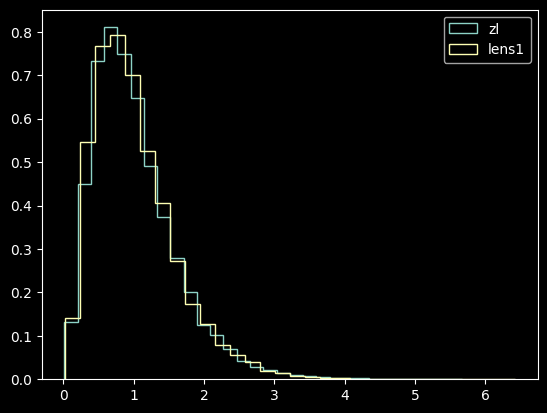

In [16]:
zs = lens1.zs_sl.rvs(20000)
zl = lens1.lens_redshift_sl.rvs(20000,zs)
zl_lens1 = param4['zl']
# plot
import matplotlib.pyplot as plt
plt.hist(zl, bins=30, density=True, label='zl', histtype='step')
plt.hist(zl_lens1, bins=30, density=True, label='lens1', histtype='step')
plt.legend()
plt.show()